In [1]:
# RISHI MAJOR PROJECT - Bank Customer Churn Prediction

In [2]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import joblib
from sklearn.inspection import permutation_importance

In [3]:
# Module 1 — Data Integration

In [29]:
# Step 1 — Load the CSV Files
demographic = pd.read_csv("C:/Users/Lenovo/Major Project/bank-churn-project/data/raw/demographic.csv")
account = pd.read_csv("C:/Users/Lenovo/Major Project/bank-churn-project/data/raw/account.csv")
location = pd.read_csv("C:/Users/Lenovo/Major Project/bank-churn-project/data/raw/location.csv")
# Step 2 — Preview the Data
print("Demographic Data")
display(demographic.head())
print("\nAccount Data")
display(account.head())
print("\nLocation Data")
display(location.head())
# Step 3 — Check Dataset Information
print("Demographic Dataset Info")
print(demographic.info())
print("\nAccount Dataset Info")
print(account.info())
print("\nLocation Dataset Info")
print(location.info())
# Step 4 — Merge Demographic and Account Data
merged_data = pd.merge(demographic, account, on="CustomerId", how="inner")
print("\nMerged Demographic + Account Data")
display(merged_data.head())
# Step 5 — Merge Location Data
final_data = pd.merge(merged_data, location, on="LocationId", how="left")
print("Final Integrated Dataset")
display(final_data.head())
# Step 6 — Check Final Dataset Shape
print("Final dataset shape:", final_data.shape)
# Step 7 — Save Merged Dataset
final_data.to_csv("C:/Users/Lenovo/Major Project/bank-churn-project/data/processed/merged_data.csv", index=False)
print("\nMerged dataset saved successfully.")

Demographic Data


,CustomerId,Name,Gender,Age,Salary,LocationId,Churned
0,15634602,Hargrave,Female,42,101348.88,2,1
1,15647311,Hill,Female,41,112542.58,6,0
2,15619304,Onio,Female,42,113931.57,4,1
3,15701354,Boni,Female,39,93826.63,1,0
4,15737888,Mitchell,Female,43,79084.10,4,0



Account Data


,AccountId,CustomerId,Tenure,Balance,NumProducts,HasCreditCard,IsActive
0,A15634602SID,15634602,2,NaN,1,1,1
1,A15647311SID,15647311,1,83807.86,1,0,1
2,A15619304SID,15619304,8,159660.80,3,1,0
3,A15701354SID,15701354,1,NaN,2,0,0
4,A15737888SID,15737888,2,125510.82,1,1,1



Location Data


...

Demographic Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerId  10000 non-null  int64  
 1   Name        10000 non-null  object 
 2   Gender      10000 non-null  object 
 3   Age         10000 non-null  int64  
 4   Salary      10000 non-null  float64
 5   LocationId  10000 non-null  int64  
 6   Churned     10000 non-null  int64  
dtypes: float64(1), int64(4), object(2)
memory usage: 547.0+ KB
None

Account Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   AccountId      10000 non-null  object 
 1   CustomerId     10000 non-null  int64  
 2   Tenure         10000 non-null  int64  
 3   Balance        6383 non-null   float64
 4   NumProducts    10000 non-null  i

,CustomerId,Name,Gender,Age,Salary,LocationId,Churned,AccountId,Tenure,Balance,NumProducts,HasCreditCard,IsActive
0,15634602,Hargrave,Female,42,101348.88,2,1,A15634602SID,2,NaN,1,1,1
1,15647311,Hill,Female,41,112542.58,6,0,A15647311SID,1,83807.86,1,0,1
2,15619304,Onio,Female,42,113931.57,4,1,A15619304SID,8,159660.80,3,1,0
3,15701354,Boni,Female,39,93826.63,1,0,A15701354SID,1,NaN,2,0,0
4,15737888,Mitchell,Female,43,79084.10,4,0,A15737888SID,2,125510.82,1,1,1


Final Integrated Dataset


,CustomerId,Name,Gender,Age,Salary,LocationId,Churned,AccountId,Tenure,Balance,NumProducts,HasCreditCard,IsActive,Geography
0,15634602,Hargrave,Female,42,101348.88,2,1,A15634602SID,2,NaN,1,1,1,France
1,15647311,Hill,Female,41,112542.58,6,0,A15647311SID,1,83807.86,1,0,1,USA
2,15619304,Onio,Female,42,113931.57,4,1,A15619304SID,8,159660.80,3,1,0,UK
3,15701354,Boni,Female,39,93826.63,1,0,A15701354SID,1,NaN,2,0,0,Germany
4,15737888,Mitchell,Female,43,79084.10,4,0,A15737888SID,2,125510.82,1,1,1,UK


Final dataset shape: (10000, 14)

Merged dataset saved successfully.


In [5]:
# Module 2 — Data Understanding

In [30]:
# Step 1 — Load the Merged Dataset
mdata = pd.read_csv("C:/Users/Lenovo/Major Project/bank-churn-project/data/processed/merged_data.csv")
print("Dataset loaded successfully.")
# Step 2 — View First Few Rows
print("\nFirst few rows:")
print(mdata.head())
# Step 3 — View Last Few Rows
print("\nLast few rows:")
print(mdata.tail())
# Step 4 — Check Dataset Shape
print("\nDataset Shape:", mdata.shape)
# Step 5 — View Column Names
print("\nColumn Names:", list(mdata.columns))
# Step 6 — Check Dataset Information
print("\nDataset Information:")
print(mdata.info())
# Step 7 — Check Data Types
print("\nData Types:")
print(mdata.dtypes)
# Step 8 — Summary Statistics
print("\nSummary Statistics:")
print(mdata.describe())
# Step 9 — Check Missing Values
missing_values = mdata.isnull().sum()
print("\nMissing values in each column:")
print(missing_values)
# Step 10 — Check Duplicate Records
duplicates = mdata.duplicated().sum()
print("\nNumber of duplicate rows:", duplicates)
# Step 11 — Check Unique Values in Categorical Columns
categorical_columns = mdata.select_dtypes(include=['object']).columns
for col in categorical_columns:
    print("\nUnique values in", col)
    print(mdata[col].unique())
# Step 12 — Check Target Variable Distribution (Churn)
print("\nChurn Count:")
print(mdata['Churned'].value_counts())
# Step 13 — Churn Percentage
churn_percentage = mdata['Churned'].value_counts(normalize=True) * 100
print("\nChurn percentage:")
print(churn_percentage)

Dataset loaded successfully.

First few rows:
   CustomerId      Name  Gender  Age     Salary  LocationId  Churned  \
0    15634602  Hargrave  Female   42  101348.88           2        1   
1    15647311      Hill  Female   41  112542.58           6        0   
2    15619304      Onio  Female   42  113931.57           4        1   
3    15701354      Boni  Female   39   93826.63           1        0   
4    15737888  Mitchell  Female   43   79084.10           4        0   

      AccountId  Tenure    Balance  NumProducts  HasCreditCard  IsActive  \
0  A15634602SID       2        NaN            1              1         1   
1  A15647311SID       1   83807.86            1              0         1   
2  A15619304SID       8  159660.80            3              1         0   
3  A15701354SID       1        NaN            2              0         0   
4  A15737888SID       2  125510.82            1              1         1   

  Geography  
0    France  
1       USA  
2        UK  
3   Germ

In [7]:
# Module 3 — Data Preprocessing

In [27]:
# Step 1 — Check Missing Values
data = mdata
print("Missing values in dataset:\n")
print(data.isnull().sum())
# Step 2 — Handle Missing Values (Fill numerical columns with mean & Fill categorical columns with mode)
num_cols = data.select_dtypes(include=['number']).columns
for col in num_cols:
    data[col] = data[col].fillna(data[col].mean())
cat_cols = data.select_dtypes(include=['object']).columns
for col in cat_cols:
    data[col] = data[col].fillna(data[col].mode()[0])
print("\nAfter handling missing values:\n")
print(data.isnull().sum())
# Step 3 — Remove Irrelevant Columns
data = data.drop(columns=["CustomerId"], errors="ignore")
print("\nFirst few rows after removing irrelevant column:")
print(data.head())
# Step 4 — Check Categorical Columns
categorical_columns = data.select_dtypes(include=["object"]).columns
print("\nCategorical Columns:")
print(categorical_columns)
# Step 5 — Encode Gender Column
data["Gender"] = data["Gender"].map({"Male": 1, "Female": 0})
# Step 6 — Encode Geography Column
data = pd.get_dummies(data, columns=["Geography"], drop_first=True, dtype=int)
# Step 7 — Verify Encoding
print("\nFirst few rows after encoding categorical data:")
print(data.head())
# Step 8 — Check Data Types After Encoding
print("\nCheck Data Types After Encoding:")
print(data.dtypes)
# Step 9 — Save Cleaned Dataset
data.to_csv("C:/Users/Lenovo/Major Project/bank-churn-project/data/processed/bank_data.csv", index=False)
print("\nProcessed dataset saved successfully!")

Missing values in dataset:

CustomerId       0
Name             0
Gender           0
Age              0
Salary           0
LocationId       0
Churned          0
AccountId        0
Tenure           0
Balance          0
NumProducts      0
HasCreditCard    0
IsActive         0
Geography        0
dtype: int64

After handling missing values:

CustomerId       0
Name             0
Gender           0
Age              0
Salary           0
LocationId       0
Churned          0
AccountId        0
Tenure           0
Balance          0
NumProducts      0
HasCreditCard    0
IsActive         0
Geography        0
dtype: int64

First few rows after removing irrelevant column:
       Name  Gender  Age     Salary  LocationId  Churned     AccountId  \
0  Hargrave  Female   42  101348.88           2        1  A15634602SID   
1      Hill  Female   41  112542.58           6        0  A15647311SID   
2      Onio  Female   42  113931.57           4        1  A15619304SID   
3      Boni  Female   39   93826.63

In [9]:
# Module 4 — Exploratory Data Analysis (EDA)

Cleaned Dataset:
       Name  Gender  Age     Salary  LocationId  Churned     AccountId  \
0  Hargrave       0   42  101348.88           2        1  A15634602SID   
1      Hill       0   41  112542.58           6        0  A15647311SID   
2      Onio       0   42  113931.57           4        1  A15619304SID   
3      Boni       0   39   93826.63           1        0  A15701354SID   
4  Mitchell       0   43   79084.10           4        0  A15737888SID   

   Tenure        Balance  NumProducts  HasCreditCard  IsActive  \
0       2  119827.493793            1              1         1   
1       1   83807.860000            1              0         1   
2       8  159660.800000            3              1         0   
3       1  119827.493793            2              0         0   
4       2  125510.820000            1              1         1   

   Geography_France  Geography_Germany  Geography_Spain  Geography_UK  \
0                 1                  0                0             

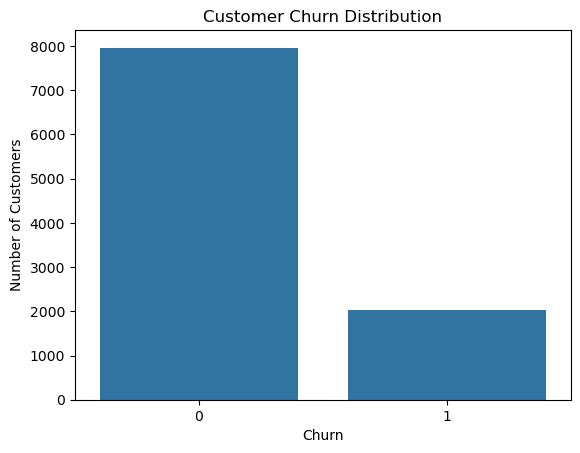

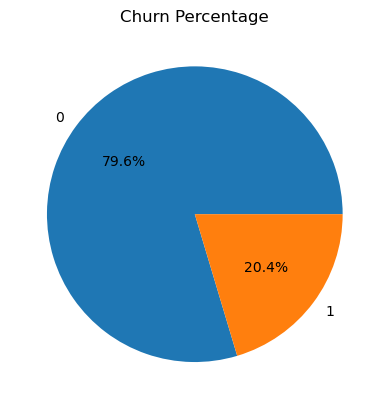

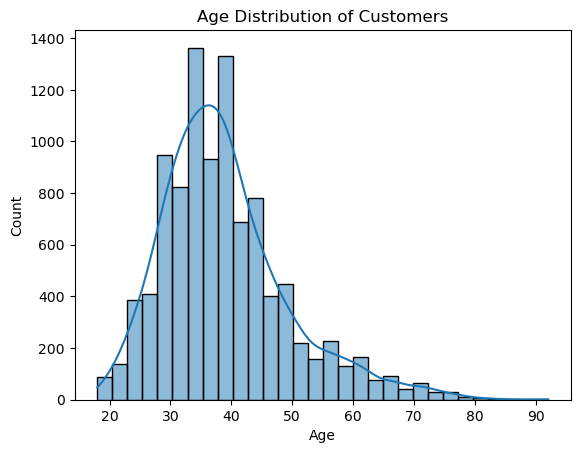

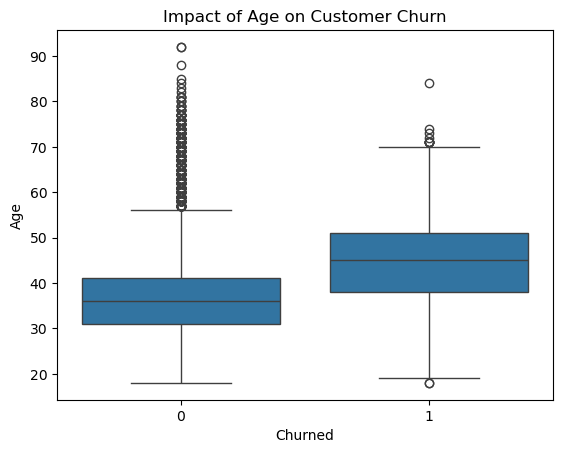

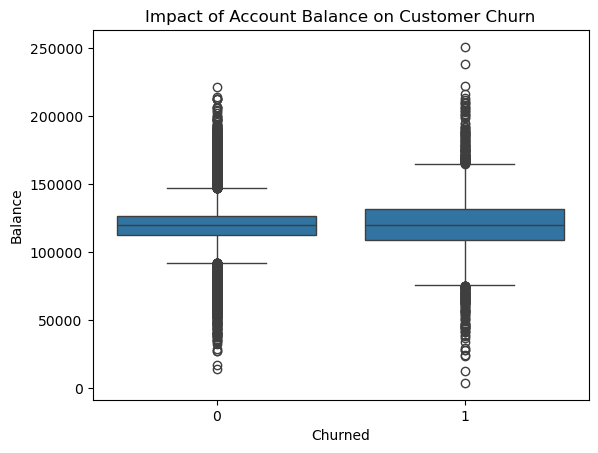

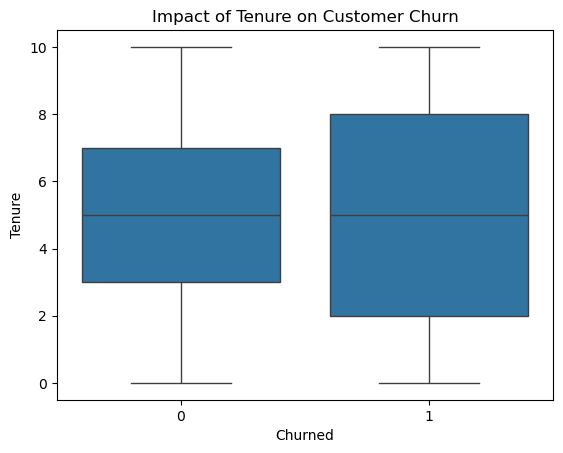

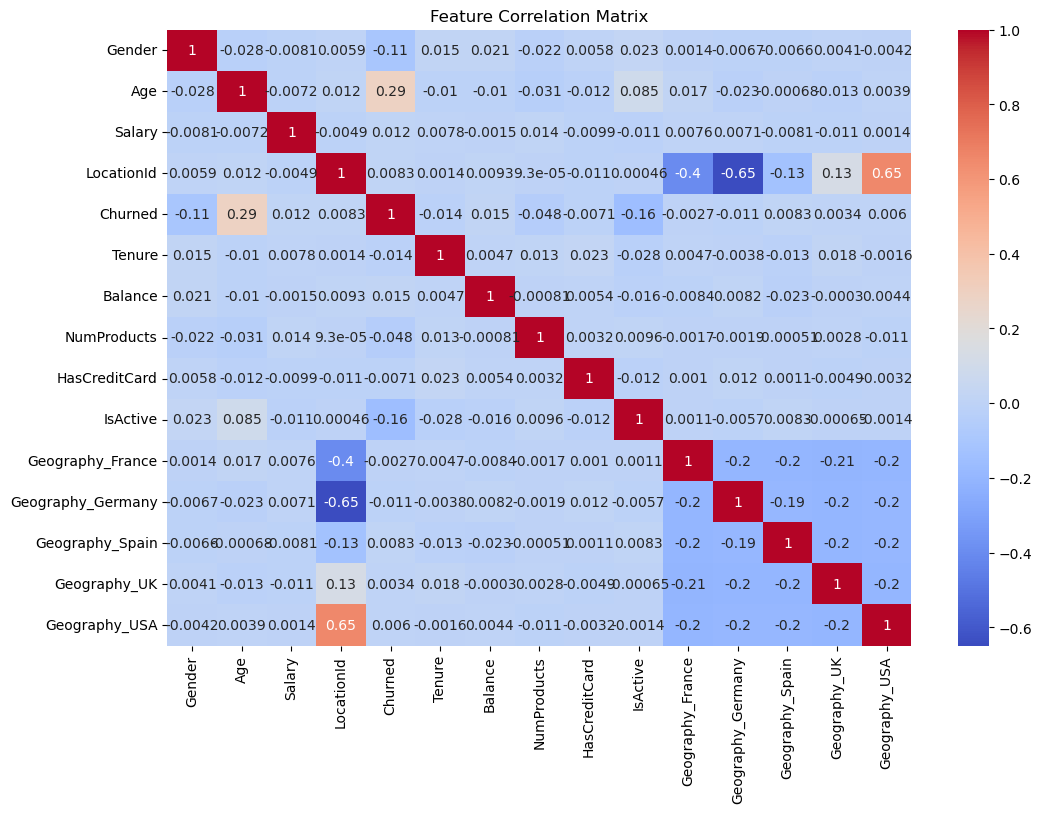

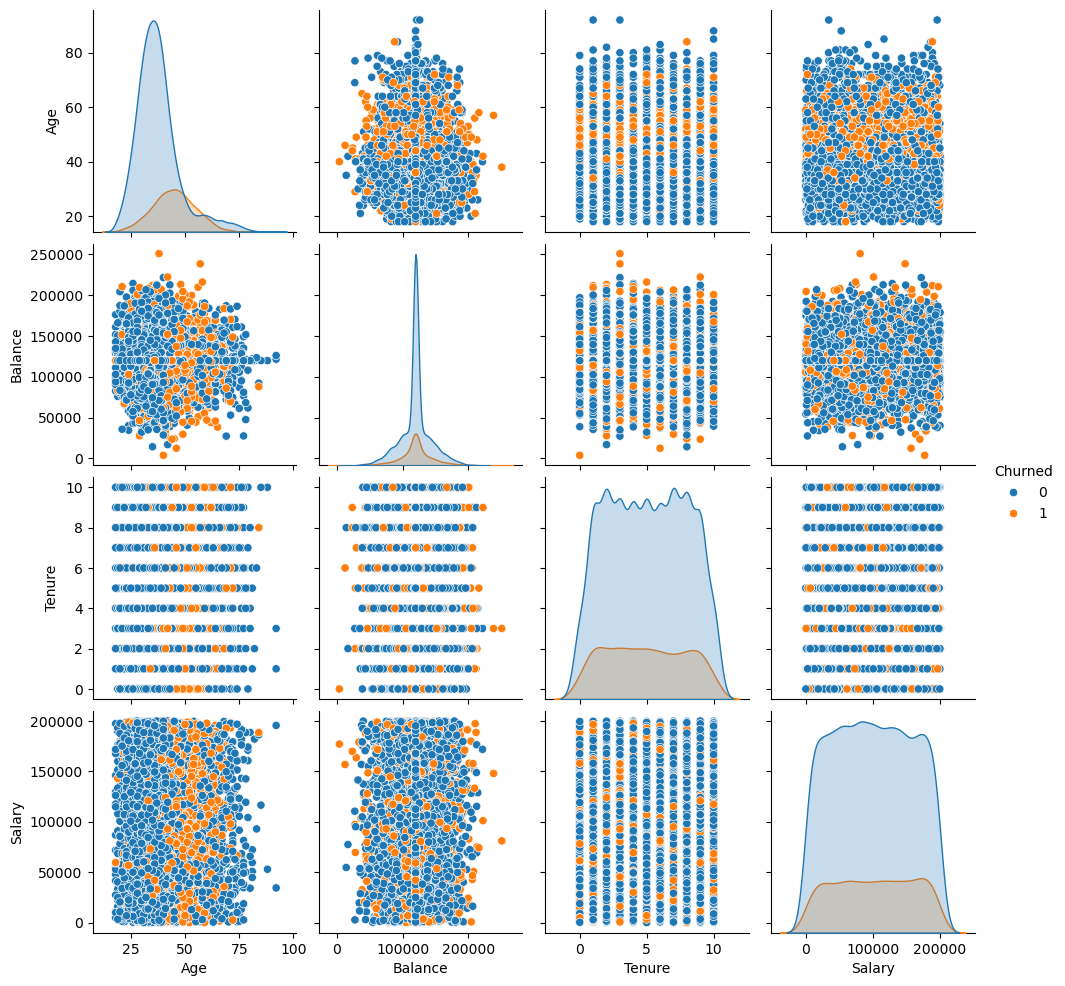

In [31]:
# Step 1 — Load Processed Dataset
pdata = pd.read_csv("C:/Users/Lenovo/Major Project/bank-churn-project/data/processed/bank_data.csv")
print("Cleaned Dataset:")
print(pdata.head())
# Step 2 — Churn Distribution
plt.figure()
sns.countplot(x="Churned", data=pdata)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()
# Step 3 — Churn Percentage Visualization
churn_counts = pdata["Churned"].value_counts()
plt.figure()
plt.pie(churn_counts, labels=churn_counts.index, autopct="%1.1f%%")
plt.title("Churn Percentage")
plt.show()
# Step 4 — Age Distribution
plt.figure()
sns.histplot(pdata["Age"], bins=30, kde=True)
plt.title("Age Distribution of Customers")
plt.show()
# Step 5 — Age vs Churn
plt.figure()
sns.boxplot(x="Churned", y="Age", data=pdata)
plt.title("Impact of Age on Customer Churn")
plt.show()
# Step 6 — Balance vs Churn
plt.figure()
sns.boxplot(x="Churned", y="Balance", data=pdata)
plt.title("Impact of Account Balance on Customer Churn")
plt.show()
# Step 7 — Tenure vs Churn
plt.figure()
sns.boxplot(x="Churned", y="Tenure", data=pdata)
plt.title("Impact of Tenure on Customer Churn")
plt.show()
# Step 8 — Correlation Matrix
plt.figure(figsize=(12,8))
corr_matrix = pdata.select_dtypes(include=['number']).corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()
# Step 9 — Feature Relationships
sns.pairplot(pdata[["Age", "Balance", "Tenure", "Salary", "Churned"]], hue="Churned")
plt.show()

In [11]:
# Module 5 — Feature Engineering

In [32]:
# Step 1 — Define Target Variable
y = pdata["Churned"]
print("Target Variable:")
print(y.head())
# Step 2 — Define Feature Variables
# Drop known useless columns
X = pdata.drop(columns=["Churned","Age"], errors="ignore")
# Remove object columns
X = X.select_dtypes(exclude=['object'])
# Debug check
print("\nRemaining non-numeric columns:")
print(X.select_dtypes(include=['object']).columns)
# Step 3 — View Feature Columns
print("\nFeature Columns:")
print(X.columns)
# Step 4 — Save Features and Target
X.to_csv("C:/Users/Lenovo/Major Project/bank-churn-project/data/processed/features.csv", index=False)
y.to_csv("C:/Users/Lenovo/Major Project/bank-churn-project/data/processed/target.csv", index=False)
print("\nFeature engineering completed successfully.")

Target Variable:
0    1
1    0
2    1
3    0
4    0
Name: Churned, dtype: int64

Remaining non-numeric columns:
Index([], dtype='object')

Feature Columns:
Index(['Gender', 'Salary', 'LocationId', 'Tenure', 'Balance', 'NumProducts',
       'HasCreditCard', 'IsActive', 'Geography_France', 'Geography_Germany',
       'Geography_Spain', 'Geography_UK', 'Geography_USA'],
      dtype='object')

Feature engineering completed successfully.


In [13]:
# Module 6 — Train-Test Split + Scaling

In [33]:
# Step 1 — Load Feature and Target Data
X = pd.read_csv("C:/Users/Lenovo/Major Project/bank-churn-project/data/processed/features.csv")
y = pd.read_csv("C:/Users/Lenovo/Major Project/bank-churn-project/data/processed/target.csv")
print("Datasets loaded successfully.\n")
# Step 2 — Convert Target to 1D
y = y.values.ravel()
# Step 3 — Perform Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train-Test Split Done")
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("\nObject columns before scaling:", X_train.select_dtypes(include=['object']).columns)
# Step 4 — Apply Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("\nFeature Scaling Applied Successfully")
joblib.dump(scaler, "C:/Users/Lenovo/Major Project/bank-churn-project/models/scaler.pkl")
print("\nScaler saved successfully.")
# Step 5 — Save Split Data
pd.DataFrame(X_train_scaled, columns=X.columns).to_csv("C:/Users/Lenovo/Major Project/bank-churn-project/data/processed/X_train_scaled.csv", index=False)
pd.DataFrame(X_test_scaled, columns=X.columns).to_csv("C:/Users/Lenovo/Major Project/bank-churn-project/data/processed/X_test_scaled.csv", index=False)
pd.DataFrame(y_train, columns=["Churned"]).to_csv("C:/Users/Lenovo/Major Project/bank-churn-project/data/processed/y_train.csv", index=False)
pd.DataFrame(y_test, columns=["Churned"]).to_csv("C:/Users/Lenovo/Major Project/bank-churn-project/data/processed/y_test.csv", index=False)
print("\nTrain-test datasets saved successfully.")

Datasets loaded successfully.

Train-Test Split Done
Training Features: (8000, 13)
Testing Features: (2000, 13)

Object columns before scaling: Index([], dtype='object')

Feature Scaling Applied Successfully

Scaler saved successfully.

Train-test datasets saved successfully.


In [15]:
# Module 7 — Machine Learning Models

Training and testing datasets loaded.

Logistic Regression model trained.
Decision Tree model trained.
Random Forest model trained.
SVM model trained.
XGBoost model trained.

All models saved successfully.

Predictions generated.



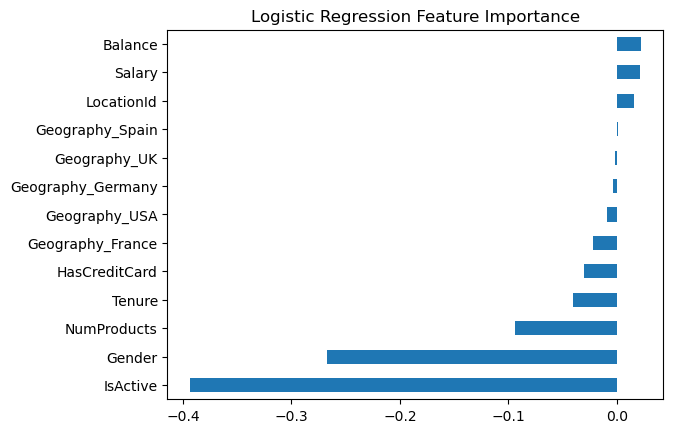

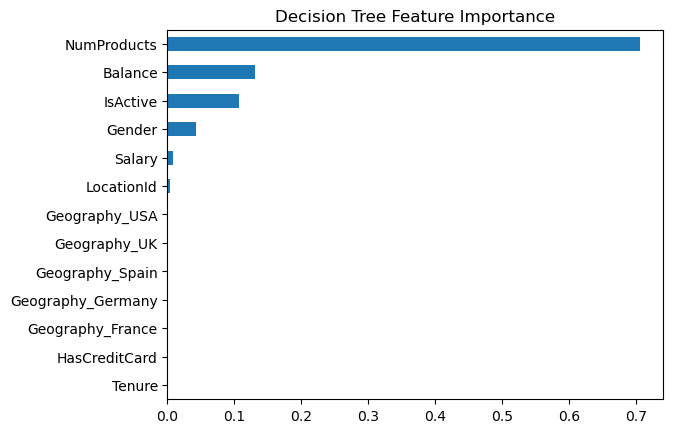

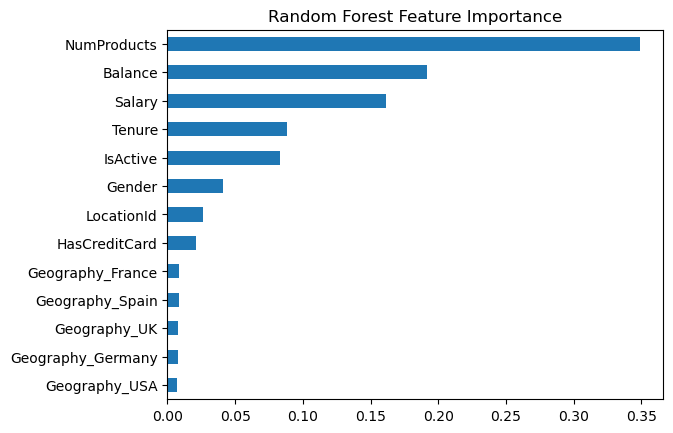

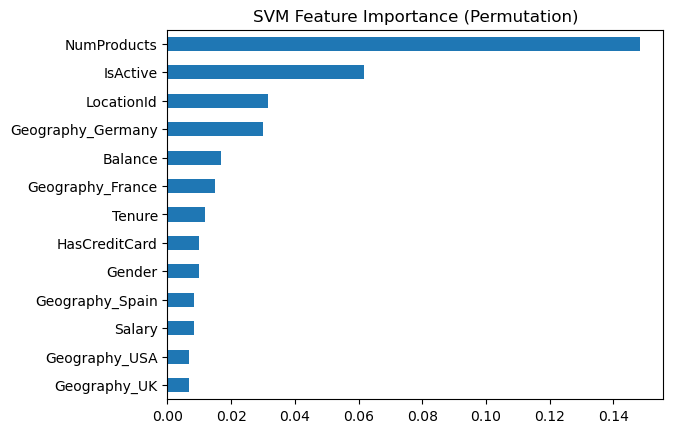

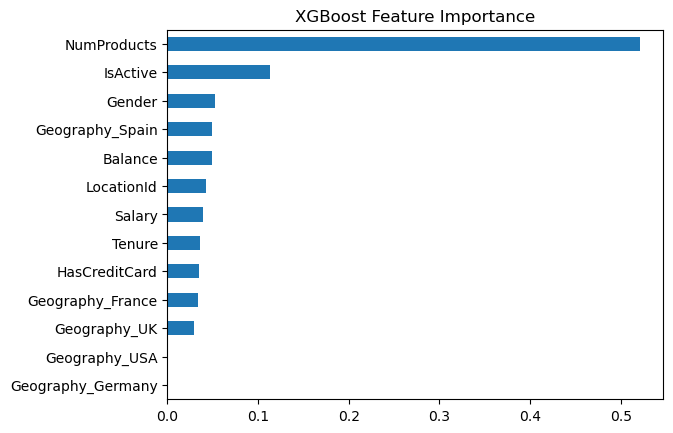


Comparison Table:
                   Logistic  DecisionTree  RandomForest   XGBoost
Gender            -0.267690      0.043325      0.040964  0.051877
Salary             0.021020      0.008681      0.161206  0.039120
LocationId         0.016103      0.004078      0.026114  0.042696
Tenure            -0.040393      0.000000      0.088162  0.035914
Balance            0.022105      0.130687      0.191305  0.048639
NumProducts       -0.093579      0.705879      0.348872  0.521089
HasCreditCard     -0.030289      0.000000      0.021432  0.034436
IsActive          -0.393517      0.107349      0.083047  0.113477
Geography_France  -0.022313      0.000000      0.008362  0.033852
Geography_Germany -0.004069      0.000000      0.007637  0.000000
Geography_Spain    0.001181      0.000000      0.008175  0.049568
Geography_UK      -0.001705      0.000000      0.007981  0.029332
Geography_USA     -0.009427      0.000000      0.006742  0.000000


In [35]:
# Step 1 — Load Training and Testing Data
X_train_scaled = pd.read_csv("C:/Users/Lenovo/Major Project/bank-churn-project/data/processed/X_train_scaled.csv")
X_test_scaled = pd.read_csv("C:/Users/Lenovo/Major Project/bank-churn-project/data/processed/X_test_scaled.csv")
y_train = pd.read_csv("C:/Users/Lenovo/Major Project/bank-churn-project/data/processed/y_train.csv")
y_test = pd.read_csv("C:/Users/Lenovo/Major Project/bank-churn-project/data/processed/y_test.csv")
print("Training and testing datasets loaded.")
# Step 2 — Convert Target Variable to 1D Array
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()
# Step 3 — Train Logistic Regression Model
log_model = LogisticRegression(class_weight="balanced")
log_model.fit(X_train_scaled, y_train)
print("\nLogistic Regression model trained.")
# Step 4 — Train Decision Tree
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42, class_weight="balanced")
dt_model.fit(X_train, y_train)
print("Decision Tree model trained.")
# Step 5 — Train Random Forest Model
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight="balanced")
rf_model.fit(X_train, y_train)
print("Random Forest model trained.")
# Step 6 — Train Support Vector Machine
svm_model = SVC(kernel='rbf', probability=True, class_weight="balanced", C=1.0, gamma='scale')
svm_model.fit(X_train_scaled, y_train)
print("SVM model trained.")
# Step 7 — Train XGBoost Model
xgb_model = XGBClassifier(eval_metric="logloss", random_state=42)
xgb_model.fit(X_train, y_train)
print("XGBoost model trained.")
# Step 8 — Save trained models
joblib.dump(log_model, "C:/Users/Lenovo/Major Project/bank-churn-project/models/logistic_model.pkl")
joblib.dump(dt_model, "C:/Users/Lenovo/Major Project/bank-churn-project/models/decision_tree_model.pkl")
joblib.dump(rf_model, "C:/Users/Lenovo/Major Project/bank-churn-project/models/random_forest_model.pkl")
joblib.dump(svm_model, "C:/Users/Lenovo/Major Project/bank-churn-project/models/svm_model.pkl")
joblib.dump(xgb_model, "C:/Users/Lenovo/Major Project/bank-churn-project/models/xgboost_model.pkl")
print("\nAll models saved successfully.")
# Step 9 — Generate Predictions
log_pred = log_model.predict(X_test_scaled) # Logistic Regression
dt_pred = dt_model.predict(X_test) # Decision Tree
rf_pred = rf_model.predict(X_test) # Random Forest
svm_pred = svm_model.predict(X_test_scaled) # SVM
xgb_pred = xgb_model.predict(X_test) # XGBoost
print("\nPredictions generated.\n")
# Step 10 — Feature Importance
log_importance = pd.Series(log_model.coef_[0], index=X_train_scaled.columns)
log_importance.sort_values().plot(kind='barh')
plt.title("Logistic Regression Feature Importance")
plt.show()
dt_importance = pd.Series(dt_model.feature_importances_, index=X_train_scaled.columns)
dt_importance.sort_values().plot(kind='barh')
plt.title("Decision Tree Feature Importance")
plt.show()
rf_importance = pd.Series(rf_model.feature_importances_, index=X_train_scaled.columns)
rf_importance.sort_values().plot(kind='barh')
plt.title("Random Forest Feature Importance")
plt.show()

result = permutation_importance( svm_model, X_test_scaled[:200], y_test[:200], n_repeats=3, random_state=42)
svm_importance = pd.Series(result.importances_mean, index=X_train_scaled.columns)
svm_importance.sort_values().plot(kind='barh')
plt.title("SVM Feature Importance (Permutation)")
plt.show()

xgb_importance = pd.Series(xgb_model.feature_importances_, index=X_train_scaled.columns)
xgb_importance.sort_values().plot(kind='barh')
plt.title("XGBoost Feature Importance")
plt.show()
importance_df = pd.DataFrame({
    "Logistic": log_importance,
    "DecisionTree": dt_importance,
    "RandomForest": rf_importance,
    "XGBoost": xgb_importance
})
print("\nComparison Table:")
print(importance_df)

In [17]:
# Module 8 — Model Evaluation

ROC-AUC calculated.
Accuracy calculated.
Precision calculated.
Recall calculated.
F1 Score calculated.

Model Comparison Table:
                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression    0.6140   0.275208  0.590331  0.375405  0.644735
1        Decision Tree    0.6885   0.358025  0.737913  0.482128  0.765144
2        Random Forest    0.7525   0.404851  0.552163  0.467169  0.759850
3                  SVM    0.7005   0.363395  0.697201  0.477768  0.749221
4              XGBoost    0.8055   0.509709  0.267176  0.350584  0.738488

Best Performing Model: Decision Tree
Final Score: 0.7003716814406694

Decision Tree saved successfully.

Classification Report of Decision Tree
              precision    recall  f1-score   support

           0       0.91      0.68      0.78      1607
           1       0.36      0.74      0.48       393

    accuracy                           0.69      2000
   macro avg       0.64      0.71      0.63      2000
weighted av

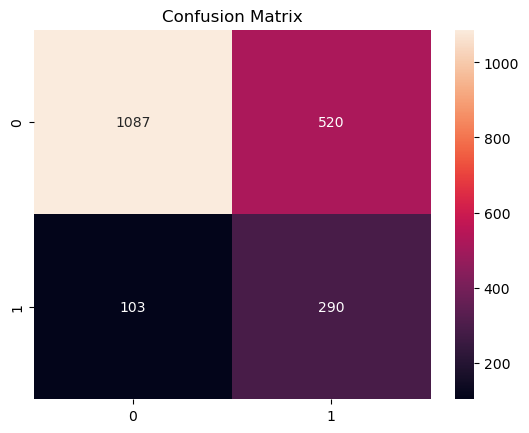

In [36]:
# Step 1 — Calculate ROC-AUC for Each Model
log_auc = roc_auc_score(y_test, log_model.predict_proba(X_test_scaled)[:, 1])
dt_auc = roc_auc_score(y_test, dt_model.predict_proba(X_test)[:, 1])
rf_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])
svm_auc = roc_auc_score(y_test, svm_model.predict_proba(X_test_scaled)[:, 1])
xgb_auc = roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:, 1])
print("ROC-AUC calculated.")
# Step 1 — Calculate Accuracy for Each Model
log_acc = accuracy_score(y_test, log_pred)
dt_acc = accuracy_score(y_test, dt_pred)
rf_acc = accuracy_score(y_test, rf_pred)
svm_acc = accuracy_score(y_test, svm_pred)
xgb_acc = accuracy_score(y_test, xgb_pred)
print("Accuracy calculated.")
# Step 2 — Calculate Precision
log_pre = precision_score(y_test, log_pred)
dt_pre = precision_score(y_test, dt_pred)
rf_pre = precision_score(y_test, rf_pred)
svm_pre = precision_score(y_test, svm_pred)
xgb_pre = precision_score(y_test, xgb_pred)
print("Precision calculated.")
# Step 3 — Calculate Recall
log_rec = recall_score(y_test, log_pred)
dt_rec = recall_score(y_test, dt_pred)
rf_rec = recall_score(y_test, rf_pred)
svm_rec = recall_score(y_test, svm_pred)
xgb_rec = recall_score(y_test, xgb_pred)
print("Recall calculated.")
# Step 4 — Calculate F1 Score
log_f1 = f1_score(y_test, log_pred)
dt_f1 = f1_score(y_test, dt_pred)
rf_f1 = f1_score(y_test, rf_pred)
svm_f1 = f1_score(y_test, svm_pred)
xgb_f1 = f1_score(y_test, xgb_pred)
print("F1 Score calculated.")
# Step 5 — Create Model Comparison Table
results = pd.DataFrame({ "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "SVM", "XGBoost"],
                         "Accuracy": [log_acc, dt_acc, rf_acc, svm_acc, xgb_acc],
                         "Precision": [log_pre, dt_pre, rf_pre, svm_pre, xgb_pre],
                         "Recall": [log_rec, dt_rec, rf_rec, svm_rec, xgb_rec],
                         "F1 Score": [log_f1, dt_f1, rf_f1, svm_f1, xgb_f1],
                        "ROC-AUC": [log_auc, dt_auc, rf_auc, svm_auc, xgb_auc] })
print("\nModel Comparison Table:")
print(results)
# Step 6 — Store predictions dictionary
models = {
    "Logistic Regression": (log_model, log_pred),
    "Decision Tree": (dt_model, dt_pred),
    "Random Forest": (rf_model, rf_pred),
    "SVM": (svm_model, svm_pred),
    "XGBoost": (xgb_model, xgb_pred)
}
# Step 7 — Find Best Model
results["Final Score"] = (0.5 * results["ROC-AUC"] + 0.3 * results["Recall"] + 0.2 * results["F1 Score"])
best_row = results.loc[results["Final Score"].idxmax()]
best_model_name = best_row["Model"]
best_model = models[best_model_name][0]
print("\nBest Performing Model:", best_model_name)
print("Final Score:", best_row["Final Score"])
joblib.dump(best_model, "C:/Users/Lenovo/Major Project/bank-churn-project/models/best_model.pkl")
print(f"\n{best_model_name} saved successfully.")
# Step 8 — Classification Report
if best_model_name == "Logistic Regression":
    pred = log_pred
elif best_model_name == "Decision Tree":
    pred = dt_pred
elif best_model_name == "Random Forest":
    pred = rf_pred
elif best_model_name == "SVM":
    pred = svm_pred
else:
    pred = xgb_pred
print(f"\nClassification Report of {best_model_name}")
print(classification_report(y_test, pred))
# Step 9 — Confusion Matrix
cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [19]:
# Module 9 — Churn Prediction System

In [37]:
# Step 1 — Load Feature Dataset
X = pd.read_csv("C:/Users/Lenovo/Major Project/bank-churn-project/data/processed/features.csv")
print("Feature dataset loaded.")
# Step 2 — Load Scaler
scaler = joblib.load("C:/Users/Lenovo/Major Project/bank-churn-project/models/scaler.pkl")
# Step 3 — Load Best Model
best_model = joblib.load("C:/Users/Lenovo/Major Project/bank-churn-project/models/best_model.pkl")
print("Best model loaded successfully.")
# Step 4 — Apply Scaling
X_scaled = scaler.transform(X)
# Step 5 — Generate Predictions
if best_model.__class__.__name__ in ["LogisticRegression", "SVC"]:
    predictions = best_model.predict(X_scaled)
    churn_probability = best_model.predict_proba(X_scaled)[:, 1]
else:
    predictions = best_model.predict(X)
    churn_probability = best_model.predict_proba(X)[:, 1]
print("\nPredictions generated.")
# Step 6 — Create Prediction DataFrame
prediction_df = X.copy()
prediction_df["Churn_Prediction"] = predictions
prediction_df["Churn_Probability"] = churn_probability
print(prediction_df.head())
# Step 7 — Identify High Risk Customers
high_risk_customers = prediction_df[prediction_df["Churn_Probability"] > 0.7]
print("\nNumber of high risk customers:", high_risk_customers.shape[0])
print(high_risk_customers.head())
# Step 8 — Save Prediction Results
prediction_df.to_csv("C:/Users/Lenovo/Major Project/bank-churn-project/data/outputs/customer_churn_predictions.csv", index=False)
print("\nPrediction results saved successfully.")

Feature dataset loaded.
Best model loaded successfully.

Predictions generated.
   Gender     Salary  LocationId  Tenure        Balance  NumProducts  \
0       0  101348.88           2       2  119827.493793            1   
1       0  112542.58           6       1   83807.860000            1   
2       0  113931.57           4       8  159660.800000            3   
3       0   93826.63           1       1  119827.493793            2   
4       0   79084.10           4       2  125510.820000            1   

   HasCreditCard  IsActive  Geography_France  Geography_Germany  \
0              1         1                 1                  0   
1              0         1                 0                  0   
2              1         0                 0                  0   
3              0         0                 0                  1   
4              1         1                 0                  0   

   Geography_Spain  Geography_UK  Geography_USA  Churn_Prediction  \
0              

In [21]:
# Module 10 — Business Insights

Dataset Loaded

   Gender     Salary  LocationId  Tenure        Balance  NumProducts  \
0       0  101348.88           2       2  119827.493793            1   
1       0  112542.58           6       1   83807.860000            1   
2       0  113931.57           4       8  159660.800000            3   
3       0   93826.63           1       1  119827.493793            2   
4       0   79084.10           4       2  125510.820000            1   

   HasCreditCard  IsActive  Geography_France  Geography_Germany  \
0              1         1                 1                  0   
1              0         1                 0                  0   
2              1         0                 0                  0   
3              0         0                 0                  1   
4              1         1                 0                  0   

   Geography_Spain  Geography_UK  Geography_USA  Churn_Prediction  \
0                0             0              0                 1   
1         

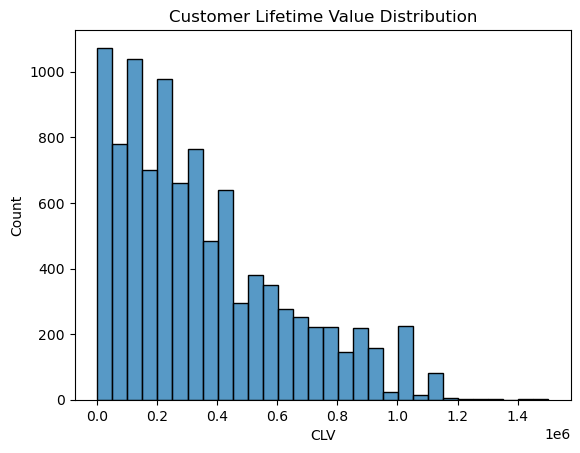


Risk Segmentation:
Risk_Segment
Medium Risk    5096
Low Risk       3620
High Risk      1282
Name: count, dtype: int64


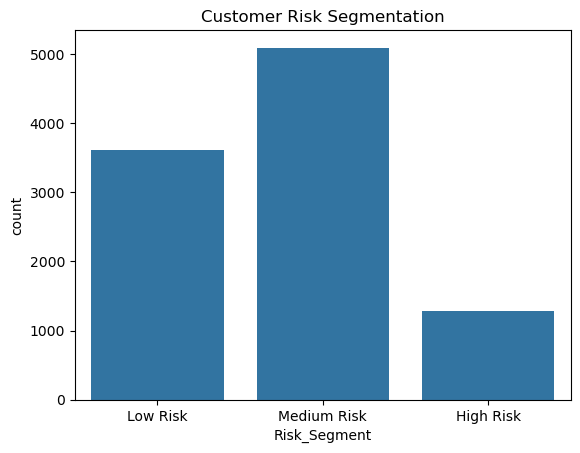


Geography-wise Churn Risk:
Geography
USA        0.429291
UK         0.427937
France     0.424904
Spain      0.423674
Germany    0.420936
Name: Churn_Probability, dtype: float64


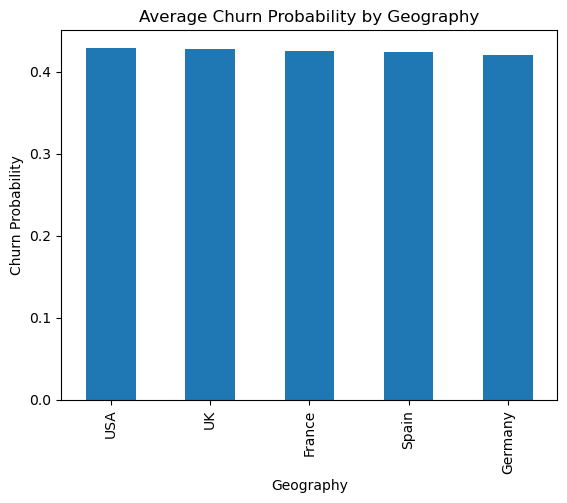


Priority Customers (High CLV + High Risk):
     Gender     Salary  LocationId  Tenure    Balance  NumProducts  \
245       0  131953.23           5      10  123497.58            1   
352       0   61936.22           4       7  169399.60            1   
406       0  173779.25           4       9  141434.04            1   
450       0   40084.32           5       7  174937.64            1   
552       0  121562.33           5      10  128509.63            1   

     HasCreditCard  IsActive  Geography_France  Geography_Germany  \
245              1         0                 0                  0   
352              1         0                 0                  0   
406              0         0                 0                  0   
450              1         0                 0                  0   
552              1         0                 0                  0   

     Geography_Spain  Geography_UK  Geography_USA  Churn_Prediction  \
245                0             0              0

In [38]:
# Step 1 — Load Prediction Dataset
ccpdata = pd.read_csv("C:/Users/Lenovo/Major Project/bank-churn-project/data/outputs/customer_churn_predictions.csv")
print("Dataset Loaded\n")
print(ccpdata.head())
# Step 2 — Customer Lifetime Value (CLV)
ccpdata["CLV"] = ccpdata["Balance"] * ccpdata["Tenure"] * (1 - ccpdata["Churn_Probability"])
print("\nCLV calculated:")
print(ccpdata[["Balance", "Tenure", "Churn_Probability", "CLV"]].head())
# Step 3 — CLV Distribution
plt.figure()
sns.histplot(ccpdata["CLV"], bins=30)
plt.title("Customer Lifetime Value Distribution")
plt.xlabel("CLV")
plt.ylabel("Count")
plt.show()
# Step 4 — Customer Risk Segmentation
ccpdata["Risk_Segment"] = pd.cut(ccpdata["Churn_Probability"], bins=[0, 0.3, 0.7, 1], labels=["Low Risk", "Medium Risk", "High Risk"])
print("\nRisk Segmentation:")
print(ccpdata["Risk_Segment"].value_counts())
# Step 5 — Risk Segment Distribution
plt.figure()
sns.countplot(x="Risk_Segment", data=ccpdata)
plt.title("Customer Risk Segmentation")
plt.show()
# Step 6 — Geographic Churn Analysis
# Convert one-hot encoding back to readable geography
geo_cols = [col for col in ccpdata.columns if "Geography_" in col]
ccpdata["Geography"] = ccpdata[geo_cols].idxmax(axis=1)
ccpdata["Geography"] = ccpdata["Geography"].str.replace("Geography_", "")
geo_churn = ccpdata.groupby("Geography")["Churn_Probability"].mean().sort_values(ascending=False)
print("\nGeography-wise Churn Risk:")
print(geo_churn)
# Visualization
plt.figure()
geo_churn.plot(kind="bar")
plt.title("Average Churn Probability by Geography")
plt.ylabel("Churn Probability")
plt.show()
# Step 7 — High Value + High Risk Customers
priority_customers = ccpdata[ (ccpdata["CLV"] > ccpdata["CLV"].median()) & (ccpdata["Risk_Segment"] == "High Risk") ]
print("\nPriority Customers (High CLV + High Risk):")
print(priority_customers.head())
print("Total Priority Customers:", priority_customers.shape[0])
# Step 8 — Business Recommendations
print("\n--- BUSINESS INSIGHTS ---")
print("1. High Risk Customers should be targeted with retention campaigns.")
print("2. High CLV + High Risk customers are TOP PRIORITY.")
print("3. Medium Risk customers can be targeted with personalized offers.")
print("4. Low Risk customers can be used for upselling products.")
# Step 9 — Save Final Dataset
ccpdata.to_csv("C:/Users/Lenovo/Major Project/bank-churn-project/data/outputs/business_insights_dataset.csv", index=False)
print("\nBusiness insights dataset saved successfully.")